# Lending Club Casestudy

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action="ignore")

In [2]:
data=pd.read_csv(r"C:\Users\KRISHNA\Desktop\datasets\loan - loan.csv")
data

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501.0,1296599.0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430.0,1314167.0,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175.0,1313524.0,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863.0,1277178.0,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358.0,1311748.0,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39714,90395.0,90390.0,5000.0,5000.0,1325.0,36 months,8.07%,156.84,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39715,90376.0,89243.0,5000.0,5000.0,650.0,36 months,7.43%,155.38,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39716,87023.0,86999.0,7500.0,7500.0,800.0,36 months,13.75%,255.43,E,E2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
rows,columns=data.shape
print(f"Dataset has {rows} rows and {columns} columns.")

Dataset has 39719 rows and 111 columns.


In [4]:
data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501.0,1296599.0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430.0,1314167.0,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175.0,1313524.0,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863.0,1277178.0,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358.0,1311748.0,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN


In [5]:
# looping through numerical and categorical to find total num
num,obj=0,0
for feature in data.columns:
    if data.dtypes[feature]!="O":
        num+=1
    else:
        obj+=1
print(f"There are {num} numerical features and {obj} categorical features.")

There are 86 numerical features and 25 categorical features.


In [6]:
data["loan_status"]

0         Fully Paid
1        Charged Off
2         Fully Paid
3         Fully Paid
4            Current
            ...     
39714     Fully Paid
39715     Fully Paid
39716     Fully Paid
39717            NaN
39718            NaN
Name: loan_status, Length: 39719, dtype: object

In [7]:
# Analysing the target column loan status

In [8]:
data["loan_status"].describe()

count          39717
unique             3
top       Fully Paid
freq           32950
Name: loan_status, dtype: object

In [9]:
data["loan_status"].isnull().sum()

np.int64(2)

In [10]:
data["loan_status"].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

In [11]:
data["loan_status"].value_counts()[0]/len(data)

np.float64(0.8295777839321231)

In [12]:
print(data["loan_status"].value_counts()[1]/len(data))
print(data["loan_status"].value_counts()[2]/len(data))

0.14167023338956167
0.02870162894332687


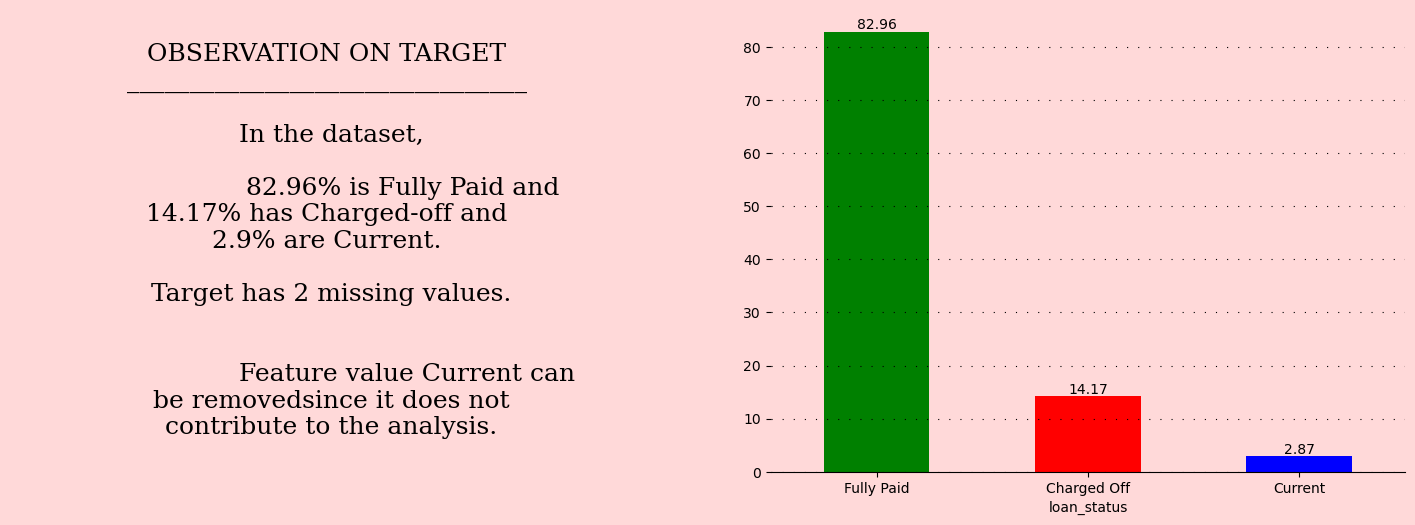

In [13]:
# creating a plot structure
fig=plt.figure(figsize=(18,6))
spec=fig.add_gridspec(1,2)
sec_1=fig.add_subplot(spec[0,0])
sec_2=fig.add_subplot(spec[0,1])

# adding color preference
bg_color="#ffd9d9"
for area in [fig,sec_1,sec_2]:
    area.set_facecolor(bg_color)

#plotting the graph
ax=(round(data["loan_status"].value_counts(normalize=True)*100,2)).plot.bar(color=["green","red","blue"])
ax.bar_label(ax.containers[0])
sec_2.grid(axis="y",color="black",ls=":",dashes=(1,9))
plt.xticks(rotation=0)

#number of missing values
m_vals=data["loan_status"].isnull().sum()

# Narrating the observation
sec_1.text(0.5,0.5, f'''OBSERVATION ON TARGET\n________________________________\n\n In the dataset,\n
                    82.96% is Fully Paid and \n 14.17% has Charged-off and \n2.9% are Current.\n\n Target has {m_vals} missing values.\n\n
                    Feature value Current can\n be removedsince it does not\n contribute to the analysis.''',
                    ha='center', va='center', size=18, fontfamily='serif')

# removing the axis
sec_1.xaxis.set_visible(False)
sec_1.yaxis.set_visible(False)

for position in ["left","right","top","bottom"]:
    for selection in [sec_1,sec_2]:
        if position=="bottom" and selection==sec_2:
            continue
        else:
            selection.spines[position].set_visible(False)

plt.show()

In [14]:
# Treatment on data based on the target column
print("Unique values in target before removal:")
print(round(data["loan_status"].value_counts(normalize=True)*100,2))

# Removing attribute value "current"
data=data[data["loan_status"]!="Current"]

#Unique values after removal
print("\n unique values in the target column after removal:")
print(round(data["loan_status"].value_counts(normalize=True)*100,2))


Unique values in target before removal:
loan_status
Fully Paid     82.96
Charged Off    14.17
Current         2.87
Name: proportion, dtype: float64

 unique values in the target column after removal:
loan_status
Fully Paid     85.41
Charged Off    14.59
Name: proportion, dtype: float64


In [15]:
# duplicated check
drows,dcols=data[data.duplicated()].shape
print("There is no duplicates." if drows == 0 else f"There are {drows} duplicates in the data")

There are 1 duplicates in the data


In [16]:
data.duplicated().sum()

np.int64(1)

In [17]:
data[data.duplicated()]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
39718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Missing values
mv_grt30_lst=[] # list to store feature with more than 30% missing values
mv_lsr30_lst=[] # list to store feature with less than 30$ missing value

for feature in data.columns:
    if(data[feature].isnull().mean()*100)>30:
        mv_grt30_lst.append(feature)
    elif 0.000 < (data[feature].isnull().mean()*100) <=30:
        mv_lsr30_lst.append(feature)
print(f"There are {len(mv_grt30_lst)} features that has more than 30% missing values.")
print(f"There are {len(mv_lsr30_lst)} features that has less than 30% missing values.")

There are 57 features that has more than 30% missing values.
There are 53 features that has less than 30% missing values.


In [19]:
# looping to find the number of numerical features with only one unique value
unum_lst=[]
for feature in data:
    if data[feature].dtype!="O" and (data[feature].nunique())==1:
        if data[feature].isnull().all(axis=0):
            continue
        else:
            unum_lst.append(feature)
print(f"{unum_lst}- are the numerical features with one unique value and not Nan")

['out_prncp', 'out_prncp_inv', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'tax_liens']- are the numerical features with one unique value and not Nan


In [20]:
data.loc[:, data.nunique() == 1]

,pymnt_plan,initial_list_status,out_prncp,out_prncp_inv,collections_12_mths_ex_med,policy_code,application_type,annual_inc_joint,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,tax_liens
0,n,f,0.0,0.0,0.0,1.0,INDIVIDUAL,annual_inc_joint,0.0,0.0,0.0,0.0
1,n,f,0.0,0.0,0.0,1.0,INDIVIDUAL,annual_inc_joint,0.0,0.0,0.0,0.0
2,n,f,0.0,0.0,0.0,1.0,INDIVIDUAL,annual_inc_joint,0.0,0.0,0.0,0.0
3,n,f,0.0,0.0,0.0,1.0,INDIVIDUAL,annual_inc_joint,0.0,0.0,0.0,0.0
5,n,f,0.0,0.0,0.0,1.0,INDIVIDUAL,annual_inc_joint,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
39714,n,f,0.0,0.0,NaN,1.0,INDIVIDUAL,annual_inc_joint,0.0,NaN,0.0,NaN
39715,n,f,0.0,0.0,NaN,1.0,INDIVIDUAL,annual_inc_joint,0.0,NaN,0.0,NaN
39716,n,f,0.0,0.0,NaN,1.0,INDIVIDUAL,annual_inc_joint,0.0,NaN,0.0,NaN
39717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,annual_inc_joint,NaN,NaN,NaN,NaN


In [21]:
# looping to find the number of categorical features with only one unique value
ucat_lst=[]
for feature in data:
    if data[feature].dtype=="O" and (data[feature].nunique())==1:
        if data[feature].isnull().all(axis=0):
            continue
        else:
            ucat_lst.append(feature)
print(f"{ucat_lst}- are the categorical features with one unique value and not Nan")

['pymnt_plan', 'initial_list_status', 'application_type', 'annual_inc_joint']- are the categorical features with one unique value and not Nan


In [22]:
# merge all the lists of features to be removed and remove that list
remove_feat=list(set(mv_grt30_lst + ucat_lst + unum_lst))

# observation
print("Number of features to be removed:",len(remove_feat))
print("Number of features in raw data:",data.shape[1])

# removing the list of features
for feature in data.columns:
    if feature in remove_feat:
        del data[feature]
print("Number of features in processed data:",data.shape[1])

Number of features to be removed: 69
Number of features in raw data: 111
Number of features in processed data: 42


In [23]:
# removing the mentioned features
#list of features to remove
rmv_lst = ['id','member_id','url','title','emp_title','out_prncp_inv','zip_code','last_credit_pull_d',
           'total_rec_late_fee', 'chargeoff_within_12_mths', 'delinq_2yrs', 'last_pymnt_d', 'revol_bal',
           'out_prncp', 'total_pymnt', 'total_rec_int', 'total_rec_prncp', 'collection_recovery_fee',
           'last_pymnt_amnt','recoveries', 'collections_12_mths_ex_med', 'tax_liens','earliest_cr_line', 'addr_state']

# count of features to be removed
print(f"Number of features to be removed: {len(rmv_lst)}")

# count of columns before removing
print(f"Number of columns before removing: {data.shape[1]}")

# removing the features from the dataframe
for feature in data.columns:
    if feature in rmv_lst:
        del data[feature]

# count of columns after removing
print(f"Number of columns after removing: {data.shape[1]}")

Number of features to be removed: 24
Number of columns before removing: 42
Number of columns after removing: 23


# DATA VALIDATION

In [24]:
# dataframe for datatype
data_type=pd.DataFrame(data.dtypes,columns=["Data_type"])

# Dataframe for missing percentage
data_missing=pd.DataFrame(np.round(data.isnull().mean()*100,2),columns=["Missing_percent"])

# dataframe for sample data
sample_data=pd.DataFrame(data.head(2).T)

# concatenating the above dataframes
data_concat=pd.concat([data_type,data_missing,sample_data],axis=1)

# renaming the dataframe columns
data_concat.rename(columns={0:"Columns_1",
                            1:"Columns_2"},
                            inplace=True)

data_concat

,Data_type,Missing_percent,Columns_1,Columns_2
loan_amnt,float64,0.01,5000.0,2500.0
funded_amnt,float64,0.01,5000.0,2500.0
funded_amnt_inv,float64,0.01,4975.0,2500.0
term,object,0.01,36 months,60 months
int_rate,object,0.01,10.65%,15.27%
installment,float64,0.01,162.87,59.83
grade,object,0.01,B,C
sub_grade,object,0.01,B2,C4
emp_length,object,2.68,10+ years,< 1 year
home_ownership,object,0.01,RENT,RENT


In [25]:
# Curing "int_rate" and "revol_util" to remove the percentage symbol using rstrip

data["revol_util"]=data["revol_util"].str.rstrip("%")
data["int_rate"]=data["int_rate"].str.rstrip("%")

# performing typecasting these two columns as they are in the form of object but we have cured it and removed the % symbol so we are going to typecast it into float datatype
data[["int_rate","revol_util"]]=data[["int_rate","revol_util"]].apply(pd.to_numeric)

# after typecasting
print("\n datatype after typecasting:")
print(data[["int_rate","revol_util"]].dtypes)


 datatype after typecasting:
int_rate      float64
revol_util    float64
dtype: object


# DERIVED COLUMNS

In [26]:
# data before  casting:
print("Data before casting:")
print(data["issue_d"].head())

# data type casting to datetime format
data["issue_d"]=pd.to_datetime(data["issue_d"],format="%b-%y")

# data after the casting
print("\n data after casting")
print(data["issue_d"].head())

Data before casting:
0    Dec-11
1    Dec-11
2    Dec-11
3    Dec-11
5    Dec-11
Name: issue_d, dtype: object

 data after casting
0   2011-12-01
1   2011-12-01
2   2011-12-01
3   2011-12-01
5   2011-12-01
Name: issue_d, dtype: datetime64[ns]


In [27]:
# deriving the issue_year and issue_month

# derive the year attribute
data["issue_year"]=data["issue_d"].dt.year

# derive the month attribute
data["issue_month"]=data["issue_d"].dt.month

# data with derived columns
print("data sample with derived columns")
data[["issue_d","issue_year","issue_month"]].head()

data sample with derived columns


,issue_d,issue_year,issue_month
0,2011-12-01,2011.0,12.0
1,2011-12-01,2011.0,12.0
2,2011-12-01,2011.0,12.0
3,2011-12-01,2011.0,12.0
5,2011-12-01,2011.0,12.0


### Missing value treatment

In [28]:
# data type of the missing features
print("Data type of missing features:")
print(data[["emp_length","revol_util","pub_rec_bankruptcies"]].dtypes)

Data type of missing features:
emp_length               object
revol_util              float64
pub_rec_bankruptcies    float64
dtype: object


In [30]:
# number of unique values
print("\n number of unique values:")
print(data[["emp_length","revol_util","pub_rec_bankruptcies"]].nunique())

# looking for mean and median for numerical data
print("Mean:",np.round(data["revol_util"].mean()))
print("Median:",np.median(data["revol_util"].quantile(0.5)))
print("STD:",np.round(data["revol_util"].std(),1))


 number of unique values:
emp_length                11
revol_util              1088
pub_rec_bankruptcies       3
dtype: int64
Mean: 49.0
Median: 49.1
STD: 28.4


In [31]:
# Missing value treatment
# replacing with mode for emp_length and pub_rec_bankruptcies
data["pub_rec_bankruptcies"]=data["pub_rec_bankruptcies"].fillna(data["pub_rec_bankruptcies"].mode()[0])
data["emp_length"]=data["emp_length"].fillna(data["emp_length"].mode()[0])


# replacing with median for revol_util
data["revol_util"]=data["revol_util"].fillna(data["revol_util"].median())

# After treatment
data.isnull().sum()

loan_amnt               2
funded_amnt             2
funded_amnt_inv         2
term                    2
int_rate                2
installment             2
grade                   2
sub_grade               2
emp_length              0
home_ownership          2
annual_inc              2
verification_status     2
issue_d                 2
loan_status             2
purpose                 2
dti                     2
inq_last_6mths          2
open_acc                2
pub_rec                 2
revol_util              0
total_acc               2
total_pymnt_inv         2
pub_rec_bankruptcies    0
issue_year              2
issue_month             2
dtype: int64

# UNIVARIATE

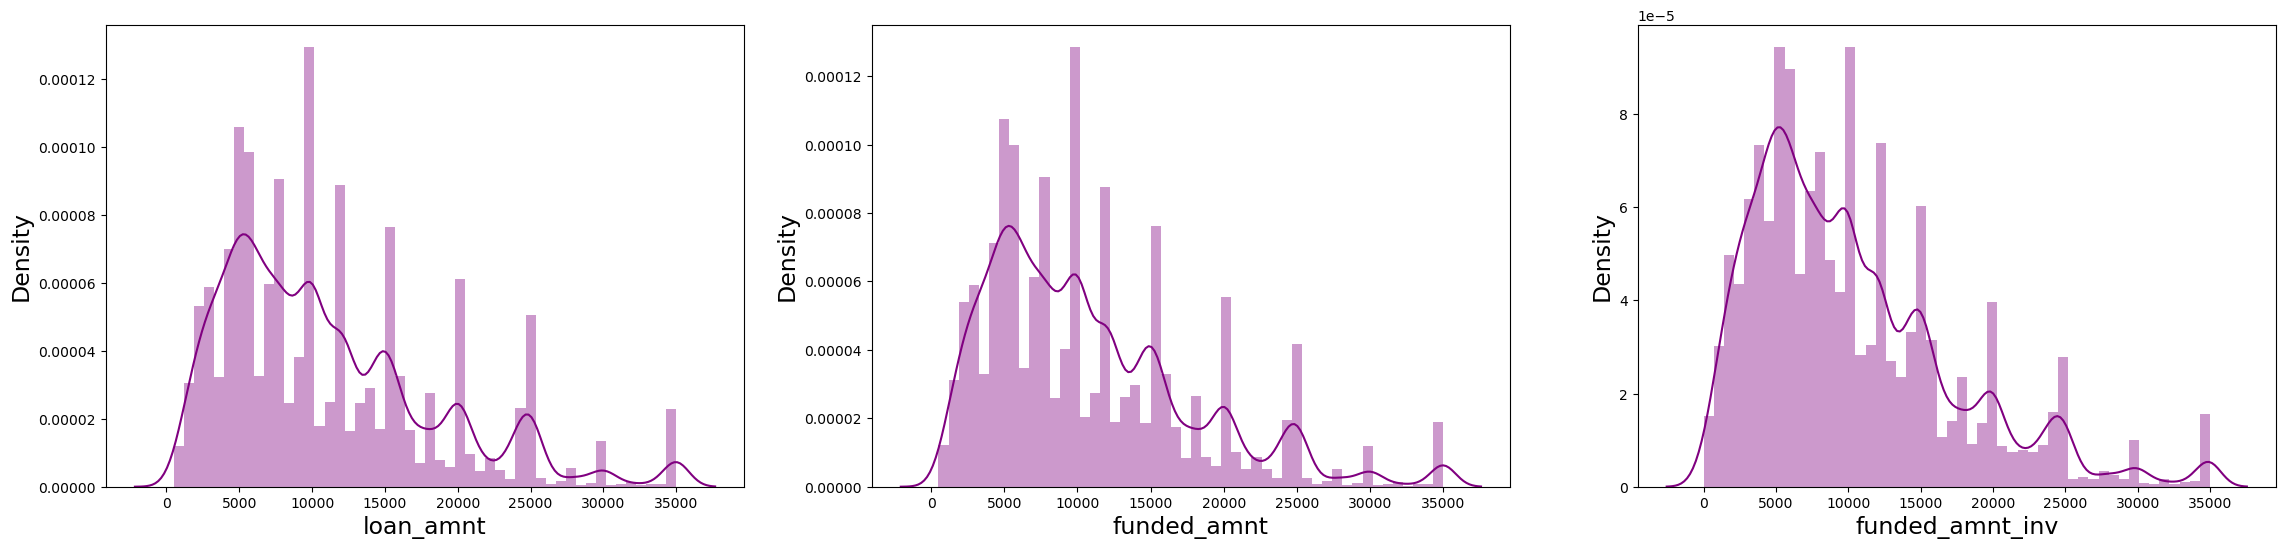

In [35]:
fig =plt.figure(figsize=(28,6))
spec = fig.add_gridspec(1,3)
spec.update(wspace=0.2, hspace=0.3)
sec_01 = fig.add_subplot(spec[0,0])
sec_02 = fig.add_subplot(spec[0,1])
sec_03 = fig.add_subplot(spec[0,2])

# Adding the color preference
bg_color ='white'
for selection in [fig,sec_01,sec_02,sec_03]:
    selection.set_facecolor(bg_color)

# Plotting the graph
sec = [sec_01,sec_02,sec_03]

cnt = 0
for feature in ['loan_amnt','funded_amnt','funded_amnt_inv']:
    sns.distplot(data[feature], ax=sec[cnt], color='purple')
    sec[cnt].set_ylabel('Density', fontsize=17)
    sec[cnt].set_xlabel(feature,fontsize=17)
    cnt+=1


plt.show()

# Observation
1. Density distribution for all the three features are similar. Hence, we can proceed forward to anlayse with any of the feature.
2. Based on the nature by description we will proceed forward with "loan_amnt".

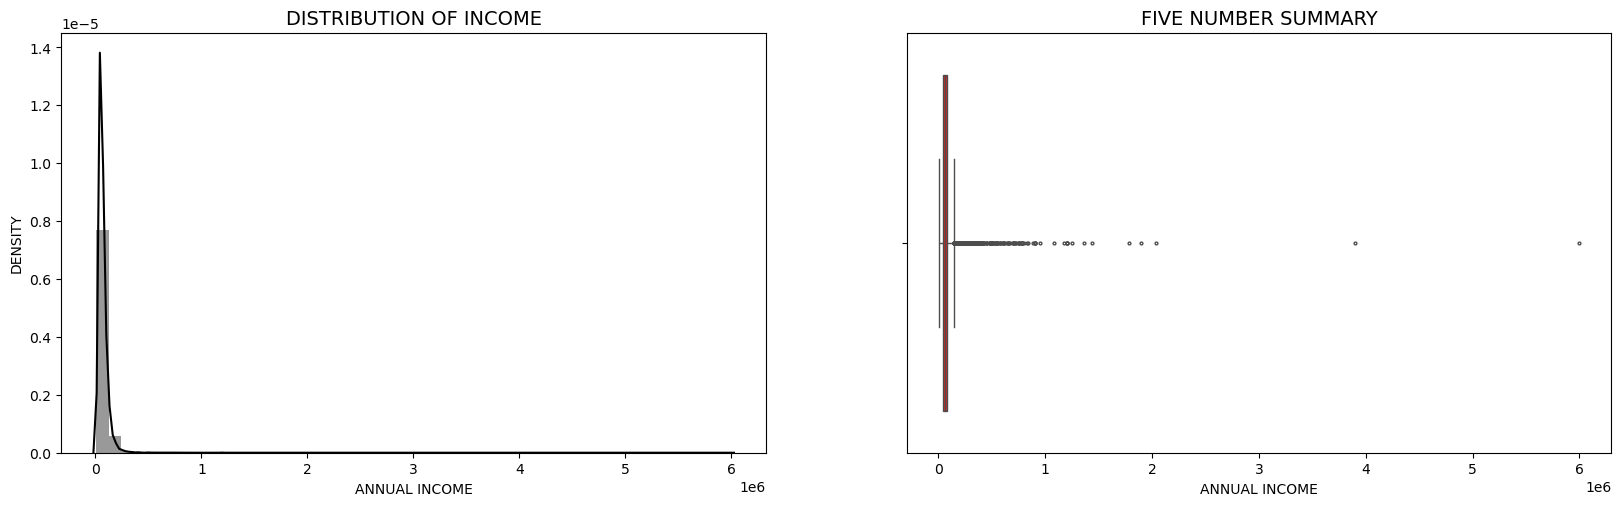

In [36]:
# Analysing annual income

# Distribution plot and outlier plot
# Distribution plot
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
viz = sns.distplot(data['annual_inc'], color='black')
viz.set_title('DISTRIBUTION OF INCOME',fontsize=14,color='black')
viz.set_ylabel('DENSITY',fontsize =10,color = 'black')
viz.set_xlabel('ANNUAL INCOME',fontsize =10,color = 'black')

# Outlier plot
plt.subplot(2,2,2)
viz = sns.boxplot(data['annual_inc'], orient='h',color='red',fliersize=2)
viz.set_title('FIVE NUMBER SUMMARY',fontsize=14,color='black')
viz.set_xlabel('ANNUAL INCOME',fontsize =10,color = 'black')
plt.show()

In [37]:
# Numerical summary
print('Numerical Summary: ')
print('Mean:', data['annual_inc'].mean())
print('Median:', data['annual_inc'].quantile(0.5))
print('90% Data', data['annual_inc'].quantile(0.9))
print('99% Data:', data['annual_inc'].quantile(0.99))
print('100% Data:', data['annual_inc'].quantile(1))

Numerical Summary: 
Mean: 68777.97368120901
Median: 58868.0
90% Data 115000.0
99% Data: 234143.99999999878
100% Data: 6000000.0


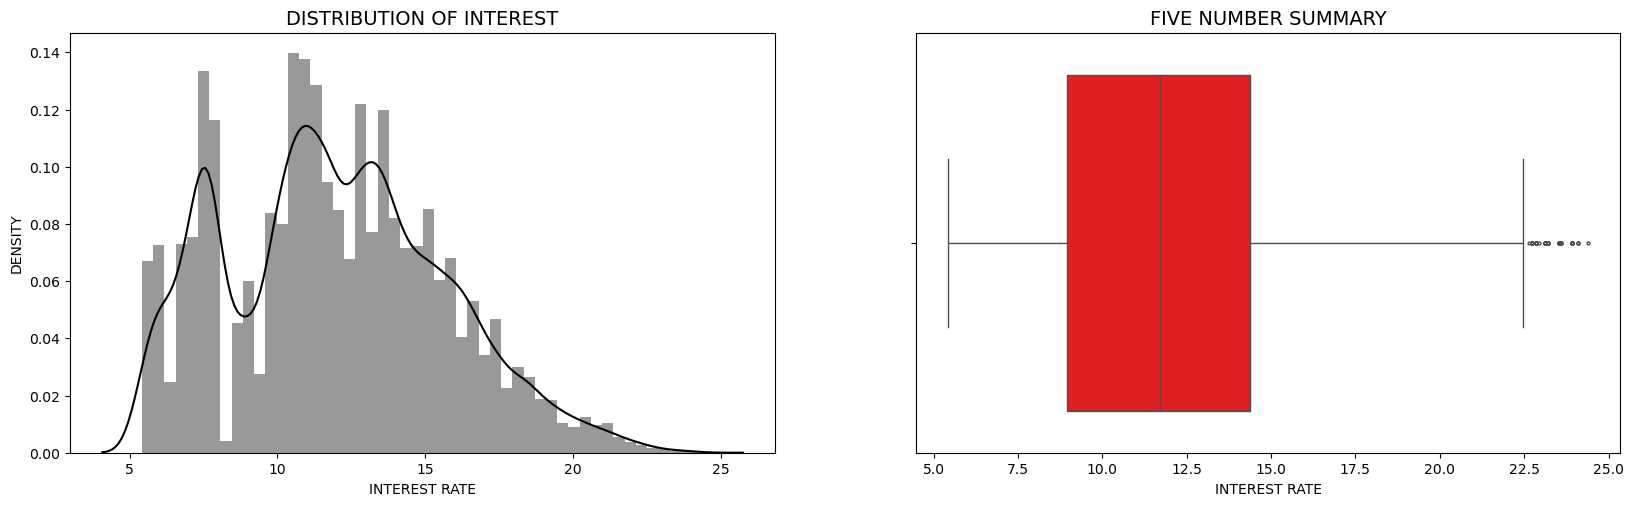

In [38]:
# Univariate Analysis on Interest Rate

# Distribution plot and outlier plot
# Distribution plot
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
viz = sns.distplot(data['int_rate'], color='black')
viz.set_title('DISTRIBUTION OF INTEREST',fontsize=14,color='black')
viz.set_ylabel('DENSITY',fontsize =10,color = 'black')
viz.set_xlabel('INTEREST RATE',fontsize =10,color = 'black')

# Outlier plot
plt.subplot(2,2,2)
viz = sns.boxplot(data['int_rate'], orient='h' ,color='red',fliersize=2)
viz.set_title('FIVE NUMBER SUMMARY',fontsize=14,color='black')
viz.set_xlabel('INTEREST RATE',fontsize =10,color = 'black')
plt.show()

In [39]:
# Numerical summary
print('Numerical Summary: ')
print('Average interest rate:',np.round(data['int_rate'].mean()),'%')
print('Interest rate @75 percentile:',np.round(data['int_rate'].quantile(0.75)),'%')
print('Interest rate @90 percentile:',np.round(data['int_rate'].quantile(0.9)),'%')
print('Interest rate @99 percentile:',np.round(data['int_rate'].quantile(0.99)),'%')
print('Interest rate @100 percentile:',np.round(data['int_rate'].quantile(1)),'%')

Numerical Summary: 
Average interest rate: 12.0 %
Interest rate @75 percentile: 14.0 %
Interest rate @90 percentile: 17.0 %
Interest rate @99 percentile: 21.0 %
Interest rate @100 percentile: 24.0 %


# Univariate on loan amount

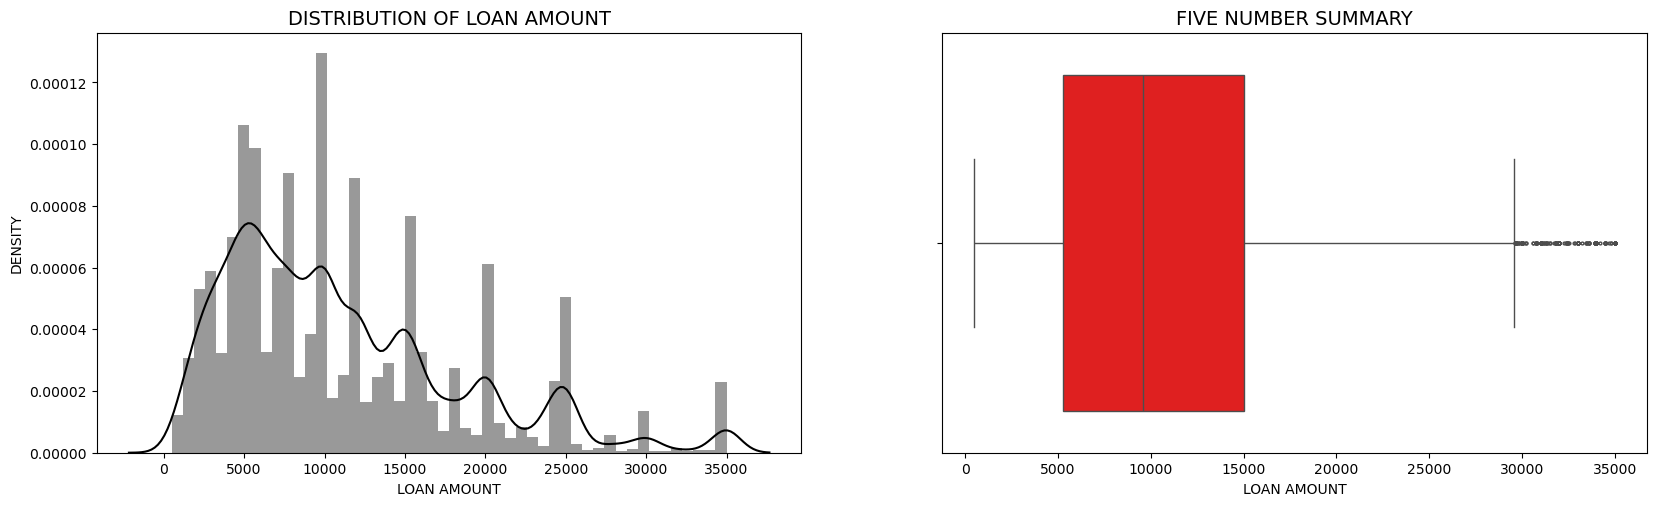

In [40]:
# Distribution plot and outlier plot
# Distribution plot
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
viz = sns.distplot(data['loan_amnt'], color='black')
viz.set_title('DISTRIBUTION OF LOAN AMOUNT',fontsize=14,color='black')
viz.set_ylabel('DENSITY',fontsize =10,color = 'black')
viz.set_xlabel('LOAN AMOUNT',fontsize =10,color = 'black')

# Outlier plot
plt.subplot(2,2,2)
viz = sns.boxplot(data['loan_amnt'], orient='h', color='red',fliersize=2)
viz.set_title('FIVE NUMBER SUMMARY',fontsize=14,color='black')
viz.set_xlabel('LOAN AMOUNT',fontsize =10,color = 'black')
plt.show()

# UNIVARIATE ANALYSIS ON LOANS / YEAR / TERM

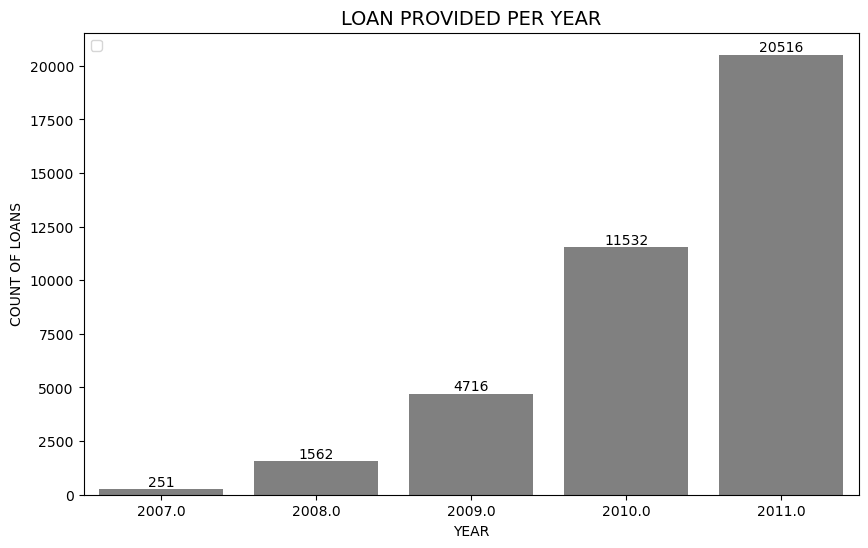

In [41]:
# Creating countplot
plt.figure(figsize=(10,6))
viz = sns.countplot(x = 'issue_year',
                    order=data['issue_year'].value_counts(ascending = True).index,
                    data=data,
                    color='grey')
viz.set_title('LOAN PROVIDED PER YEAR',fontsize=14,color='black')
viz.set_xlabel('YEAR',fontsize =10,color = 'black')
viz.set_ylabel('COUNT OF LOANS',fontsize =10,color = 'black')
viz.legend(loc=2)
viz.bar_label(viz.containers[0])
plt.show()

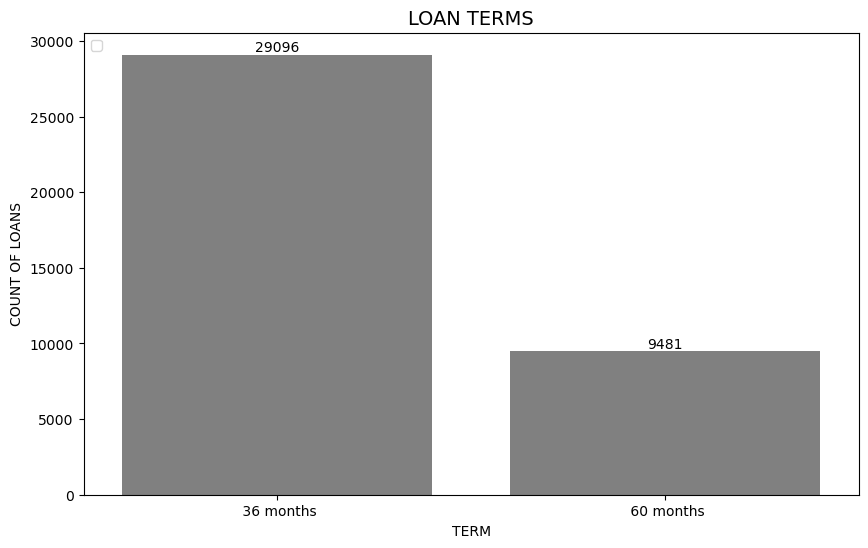

In [42]:
# Creating countplot
plt.figure(figsize=(10,6))
viz = sns.countplot(x = 'term',
                    data=data,
                    color='grey')
viz.set_title('LOAN TERMS',fontsize=14,color='black')
viz.set_xlabel('TERM',fontsize =10,color = 'black')
viz.set_ylabel('COUNT OF LOANS',fontsize =10,color = 'black')
viz.legend(loc=2)
viz.bar_label(viz.containers[0])
plt.show()

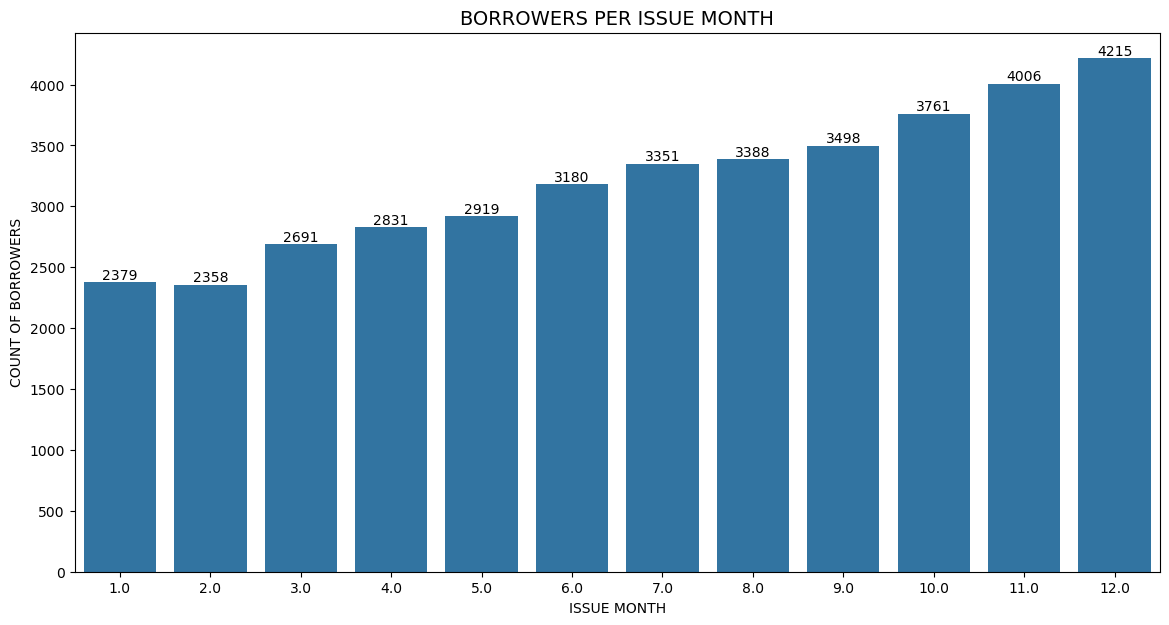

In [43]:
# Count plot for issue month
plt.figure(figsize=(14,7))
# plt.subplot(2,2,1)
viz = sns.countplot(x='issue_month', data=data)
viz.set_title('BORROWERS PER ISSUE MONTH',fontsize=14,color='black')
viz.set_ylabel('COUNT OF BORROWERS',fontsize =10,color = 'black')
viz.set_xlabel('ISSUE MONTH',fontsize =10,color = 'black')
viz.bar_label(viz.containers[0])
plt.show()

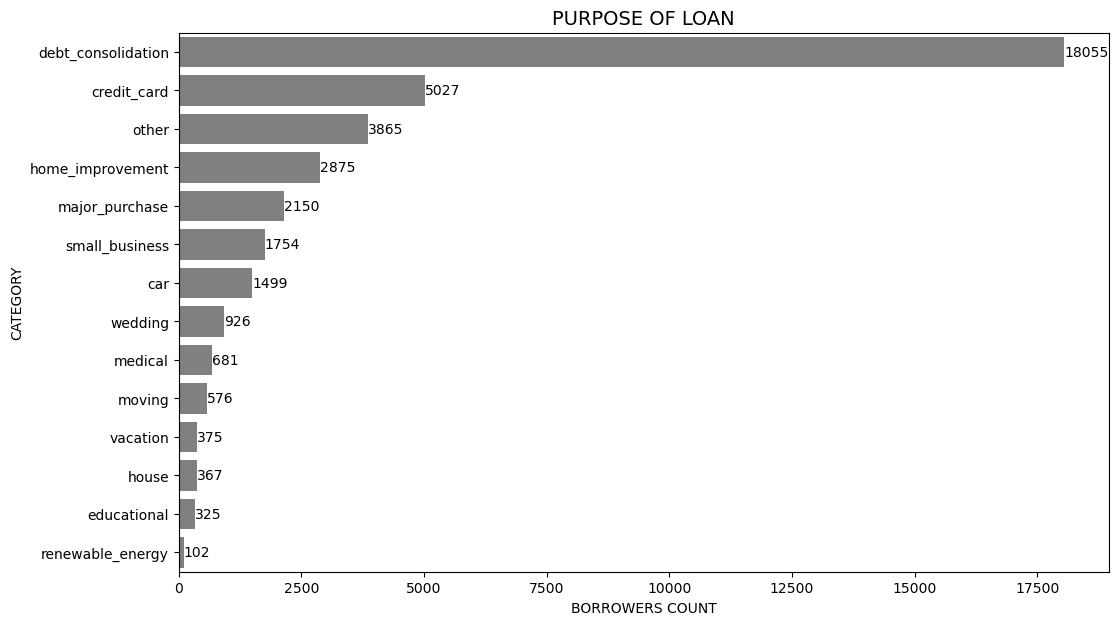

In [44]:
# Countplot for purpose
plt.figure(figsize=(12,7))
viz = sns.countplot(y=data['purpose'],
                    order=data['purpose'].value_counts().index,
                    color='grey')
viz.set_title('PURPOSE OF LOAN',fontsize=14,color='black')
viz.set_ylabel('CATEGORY',fontsize =10,color = 'black')
viz.set_xlabel('BORROWERS COUNT',fontsize =10,color = 'black')
viz.bar_label(viz.containers[0])
plt.show()

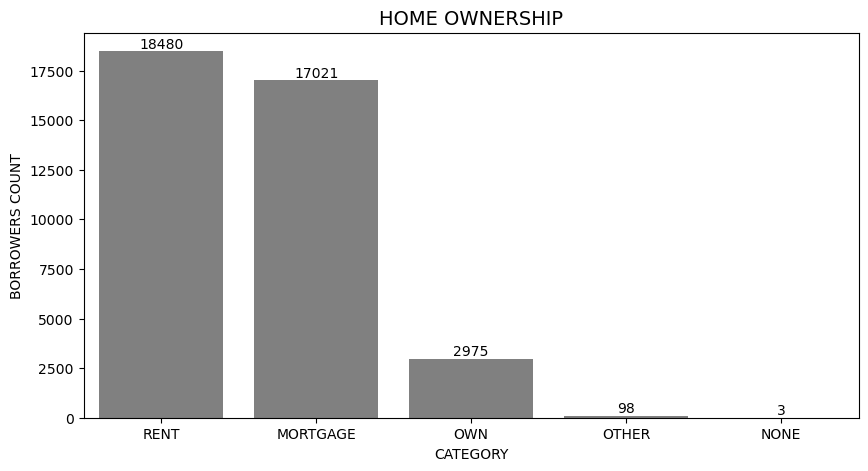

In [45]:
# Countplot for home ownership
plt.figure(figsize=(10,5))
viz = sns.countplot(x = 'home_ownership',
                    data = data,
                    order = data['home_ownership'].value_counts().index,
                    color = 'grey')
viz.set_title('HOME OWNERSHIP',fontsize=14,color='black')
viz.set_xlabel('CATEGORY',fontsize =10,color = 'black')
viz.set_ylabel('BORROWERS COUNT',fontsize =10,color = 'black')
viz.bar_label(viz.containers[0])
plt.show()

# OBSERVATION ON UNIVARIATE ANALYSIS
1. Looks like the feature "annual_inc" has outliers in the upper fence
2. There is a huge jump between 99 and 100 % of data in "annual_inc" and that can be trimmed.
3. The average interest rate is 12% but there is huge jump after 75 percentile.
4. Most of the borrowers has been provided loan with interest rate between 9% to 14%.
5. Most of the borrowers prefer to get loan amount between 5k to 15k.
6. For each year number of borrowers are increasing.
7. More borrowers are opting for 36 months loan.
8. More loans are borrowed in Q4.
9. Most of the borrowings happens for debt consolidation and credit card bill payment.
10. Very least borrowers has own house.

# OUTLIER TREATMENT

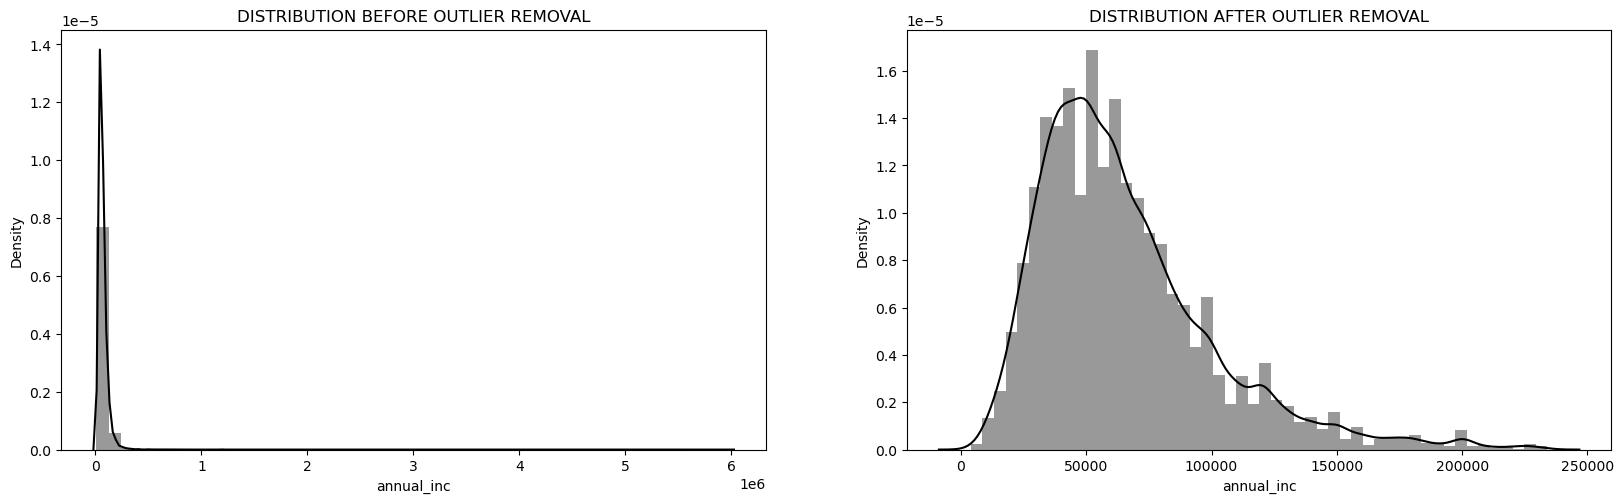

In [46]:
# Removing the data above 99% in upper fence of annual income

# Distribution plot before outlier removal
plt.figure(figsize=(20,12))
plt.subplot(2,2,1)
ax = sns.distplot(data['annual_inc'], color='black')
ax.set_title('DISTRIBUTION BEFORE OUTLIER REMOVAL')

# Removing outliers
data = data[data['annual_inc'] < data['annual_inc'].quantile(0.99)]

# Distribution plot after outlier removal
plt.subplot(2,2,2)
ax = sns.distplot(data['annual_inc'], color='black')
ax.set_title('DISTRIBUTION AFTER OUTLIER REMOVAL')
plt.show()

# Understanding the financial feature

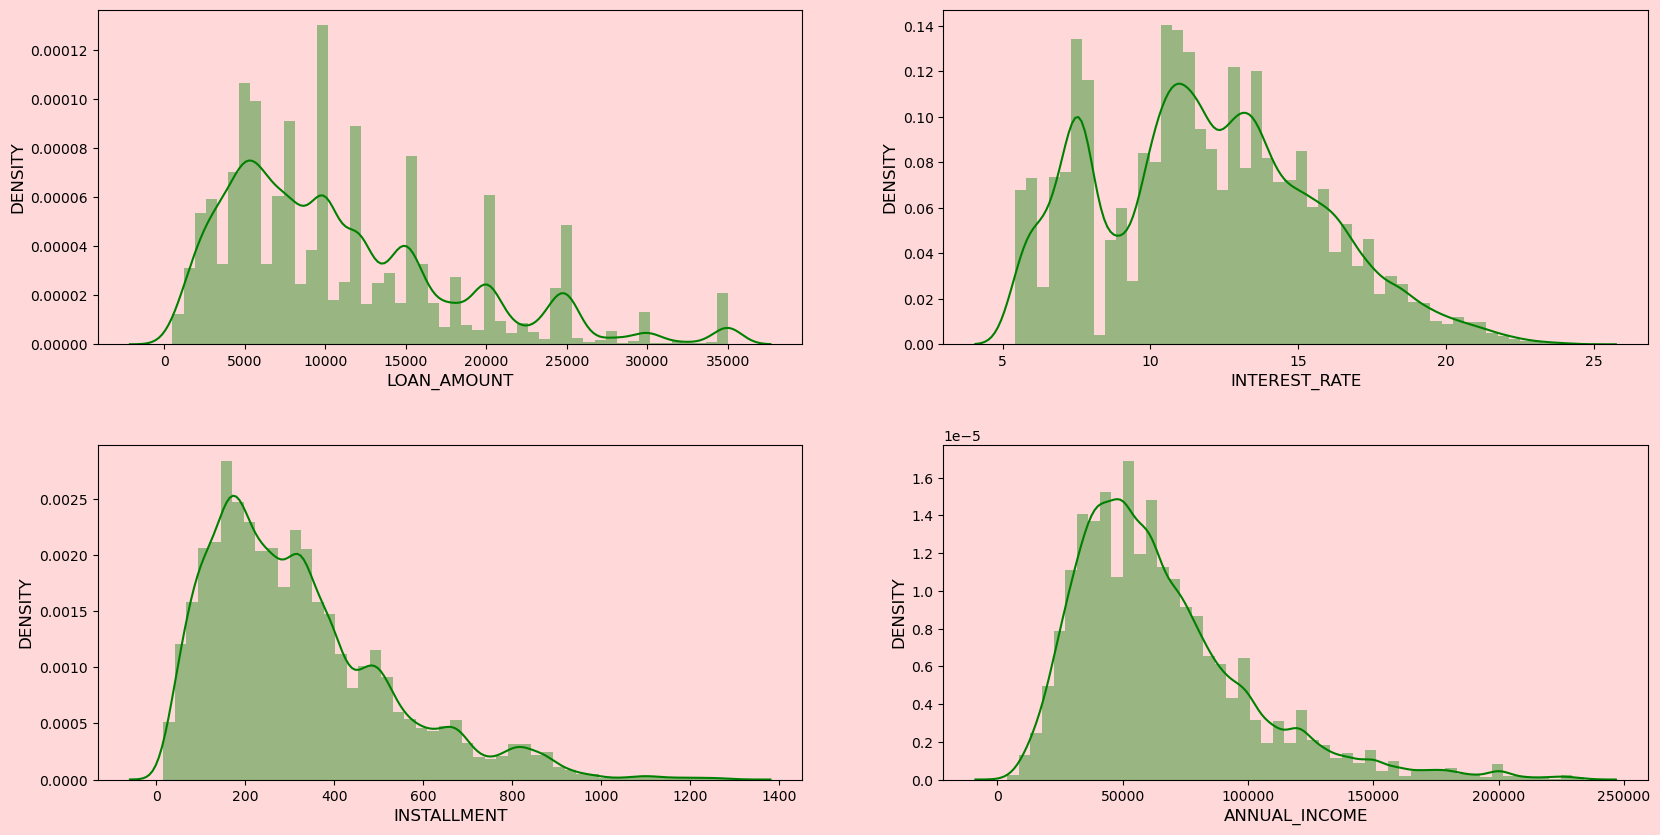

In [47]:
# Creating plots
fig = plt.figure(figsize=(20,10))
spec = fig.add_gridspec(2,2)
spec.update(wspace=0.2, hspace=0.3)
sec_01 = fig.add_subplot(spec[0,0])
sec_02 = fig.add_subplot(spec[0,1])
sec_03 = fig.add_subplot(spec[1,0])
sec_04 = fig.add_subplot(spec[1,1])

# Adding color preference
bg_color = '#ffd9d9'
for selection in [fig, sec_01, sec_02, sec_03, sec_04]:
    selection.set_facecolor(bg_color)

# Plotting the graph
sec = [sec_01, sec_02, sec_03, sec_04]

cnt = 0
for feature in ["loan_amnt", "int_rate", "installment", "annual_inc"]:
    sns.distplot(data[feature], ax=sec[cnt], color='green')
    sec[cnt].set_ylabel('DENSITY' , fontsize=12)
    cnt+=1

# Naming the axis
sec_01.set_xlabel('LOAN_AMOUNT' , fontsize=12)
sec_02.set_xlabel('INTEREST_RATE' , fontsize=12)
sec_03.set_xlabel('INSTALLMENT' , fontsize=12)
sec_04.set_xlabel('ANNUAL_INCOME' , fontsize=12)

plt.show()

Based on the nature of distribution "loan_amnt", "int_rate", "annual_inc", "installment" can be bucketed for further analysis.

# CREATING BUCKETS FOR BIVARIATE ANALYSIS

In [48]:
# Creating categorical buckets for loan amount
data["loan_amnt_bkt"] = pd.cut(data['loan_amnt'],
                               list(range(0,40001,7000)),
                               labels = ['0 - 7k', '7k - 14k', '14k - 21k', '21k - 28k', '28k+'])

# Creating categorical buckets for interest rate
data["int_rate_bkt"] = pd.cut(data['int_rate'],
                               list(range(5,26,5)),
                               labels = ['5 - 10', '10 - 15', '15 - 20', '20+'])


# Creating categorical buckets for annual income
data['annual_inc_bkt'] = pd.cut(data['annual_inc'],
                                 list(range(0,250001,50000)),
                                 labels = ['0 - 50k', '50k - 100k', '100k - 150k', '150k - 200k', '200k+'])

# Creating categorical buckets for installment
data["installment_bkt"] = pd.cut(data['installment'],
                               list(range(0,1401,200)),
                               labels = ['0 - 200', '200 - 400', '400 - 600', '600 - 800',
                                         '800 - 1000', '1000 - 12000', '12000+'])

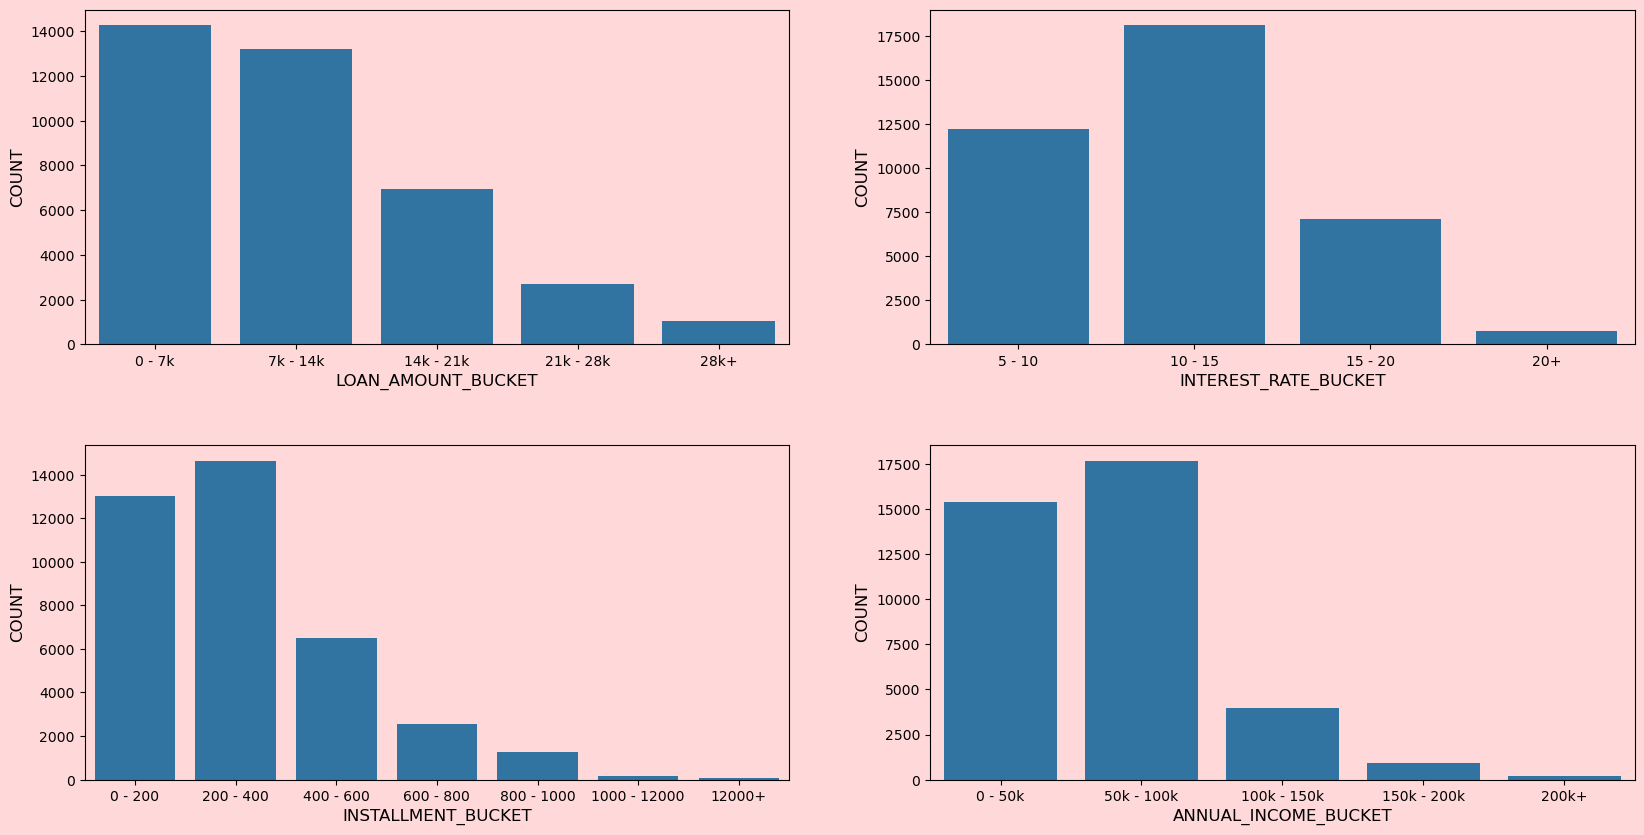

In [49]:
# Creating plots
fig = plt.figure(figsize=(20,10))
spec = fig.add_gridspec(2,2)
spec.update(wspace=0.2, hspace=0.3)
sec_01 = fig.add_subplot(spec[0,0])
sec_02 = fig.add_subplot(spec[0,1])
sec_03 = fig.add_subplot(spec[1,0])
sec_04 = fig.add_subplot(spec[1,1])

# Adding color preference
bg_color = '#ffd9d9'
for selection in [fig, sec_01, sec_02, sec_03, sec_04]:
    selection.set_facecolor(bg_color)

# Plotting the graph
sec = [sec_01, sec_02, sec_03, sec_04]

cnt = 0
for feature in ['loan_amnt_bkt', 'int_rate_bkt', 'installment_bkt', 'annual_inc_bkt']:
    sns.countplot(x=feature, data=data, ax=sec[cnt])
    sec[cnt].set_ylabel('COUNT' , fontsize=12)
    cnt+=1

# Naming the axis
sec_01.set_xlabel('LOAN_AMOUNT_BUCKET' , fontsize=12)
sec_02.set_xlabel('INTEREST_RATE_BUCKET' , fontsize=12)
sec_03.set_xlabel('INSTALLMENT_BUCKET' , fontsize=12)
sec_04.set_xlabel('ANNUAL_INCOME_BUCKET' , fontsize=12)

plt.show()

# Bivariate Analysis
1. Moving forward in bivariate analysis we just need the data of "Charged Off" borrowers.
2. So, we create a new dataframe that has only "Charged Off" borrowers data.

In [50]:
# Creating dataframe with feature value "Charged Off":
co_data = data[data['loan_status'] == 'Charged Off']

# Looking into the nature of data:
print(f'The trimmed data has {co_data.shape[0]} rows and {co_data.shape[1]} columns')
print(f'The unique value is {co_data["loan_status"].unique()}')

The trimmed data has 5584 rows and 29 columns
The unique value is ['Charged Off']


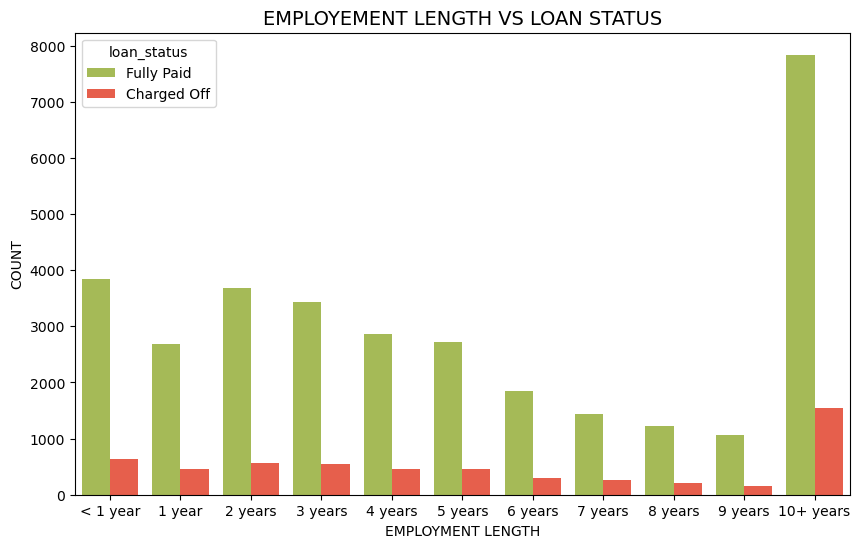

In [51]:
# Countplot for employment length by loan status as hue
plt.figure(figsize=(10,6))
ax = sns.countplot(x = 'emp_length',
              hue = 'loan_status',
              order=['< 1 year',  '1 year','2 years','3 years', '4 years',
                     '5 years', '6 years', '7 years',  '8 years', '9 years', '10+ years'],
              palette=['#AECB46', "#FF4C33"],
              data = data)

# Naming the axis and title
ax.set_title('EMPLOYEMENT LENGTH VS LOAN STATUS',fontsize=14,color='black')
ax.set_ylabel('COUNT',fontsize =10,color = 'black')
ax.set_xlabel('EMPLOYMENT LENGTH',fontsize =10,color = 'black')
plt.show()

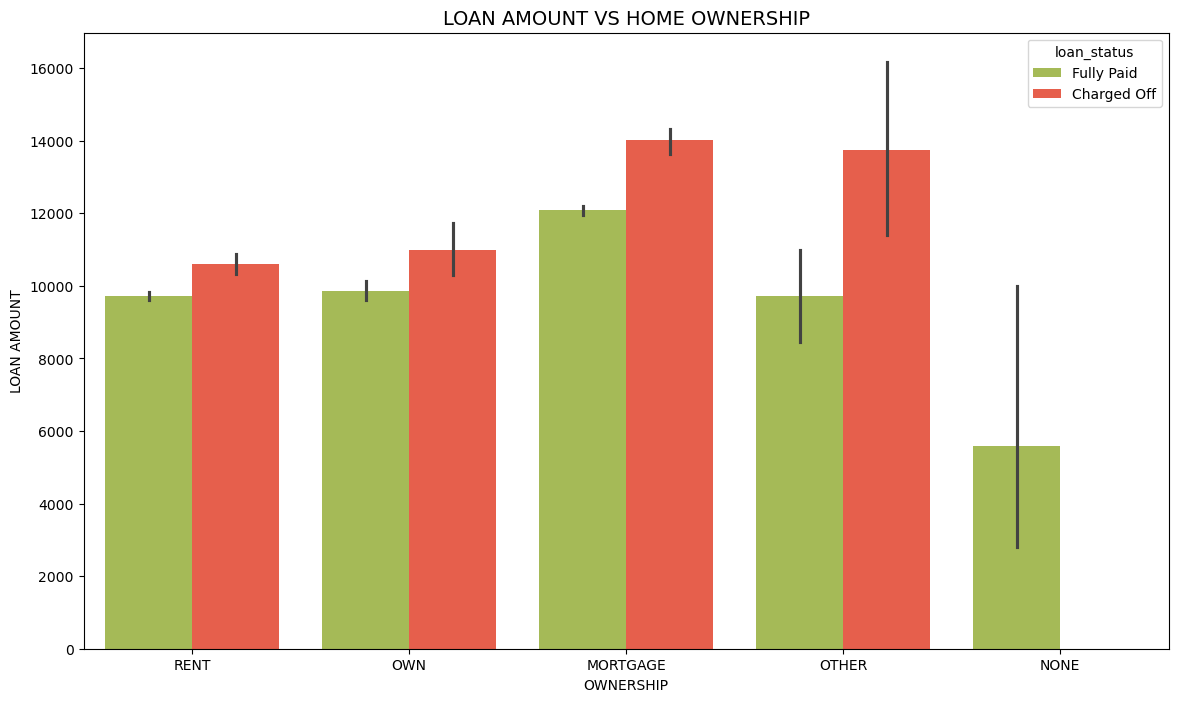

In [52]:
# Bar plot for loan amount by home ownership
plt.figure(figsize=(14,8))
ax = sns.barplot(data =data,
                 x='home_ownership',
                 y='loan_amnt',
                 hue ='loan_status',
                 palette=['#AECB46', "#FF4C33"])

# Naming the axis and title
ax.set_title('LOAN AMOUNT VS HOME OWNERSHIP',fontsize=14,color='black')
ax.set_xlabel('OWNERSHIP',fontsize =10,color = 'black')
ax.set_ylabel('LOAN AMOUNT',fontsize =10,color = 'black')
plt.show()

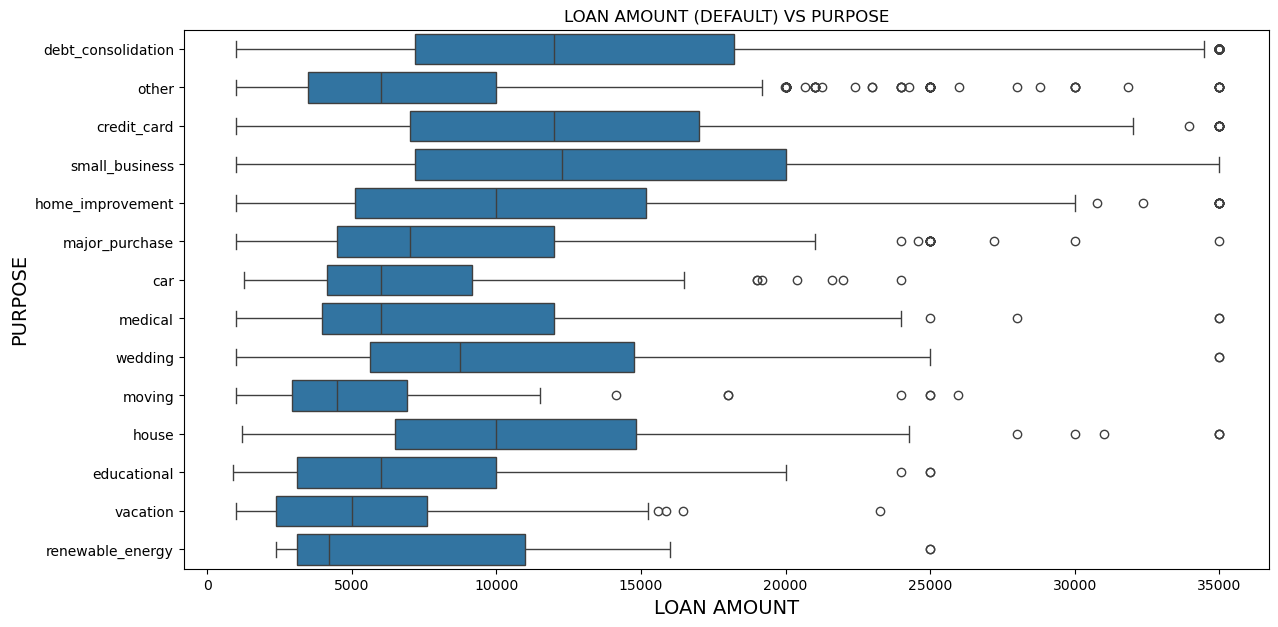

In [53]:
# Box plot for loan amount vs purpose
plt.figure(figsize=(14,7))
viz = sns.boxplot(x='loan_amnt',
            y='purpose',
            order=co_data['purpose'].value_counts().index,
            data=co_data)

# Naming the axis and title
viz.set_xlabel('LOAN AMOUNT', fontsize = 14)
viz.set_ylabel('PURPOSE', fontsize = 14)
viz.set_title('LOAN AMOUNT (DEFAULT) VS PURPOSE')
plt.show()

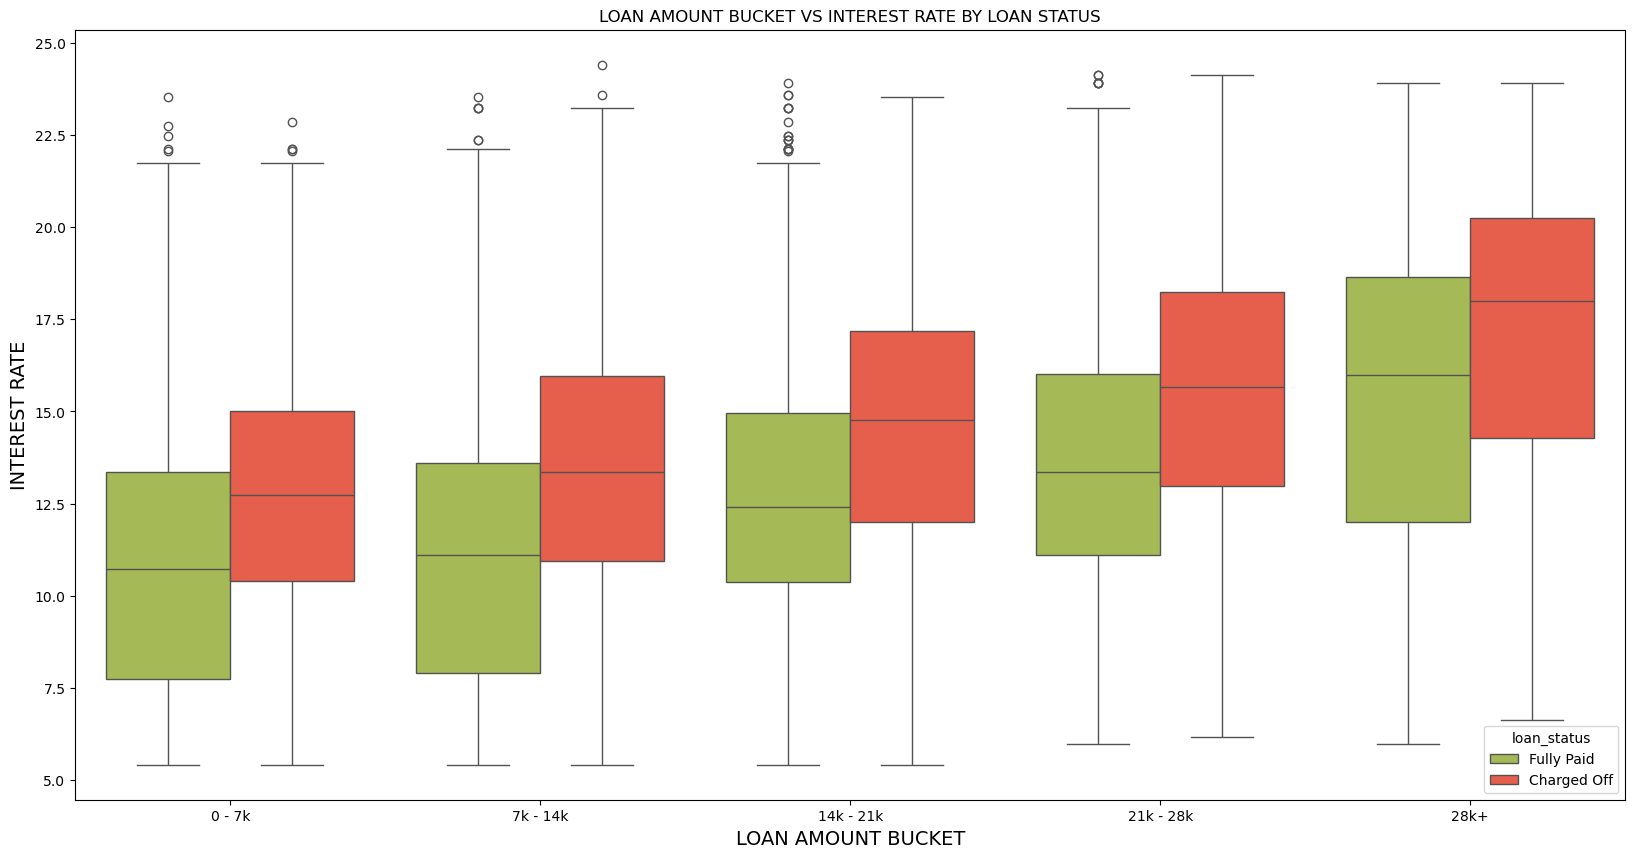

In [54]:
# Box plot for loan amount bucket vs interest rate by loan status as hue
plt.figure(figsize=(20,10))
viz = sns.boxplot(x='loan_amnt_bkt',
            y='int_rate',
            hue = 'loan_status',
            order=data['loan_amnt_bkt'].value_counts().index,
            palette=['#AECB46', "#FF4C33"],
            data=data)

# Naming the axis and title
viz.set_xlabel('LOAN AMOUNT BUCKET', fontsize = 14)
viz.set_ylabel('INTEREST RATE', fontsize = 14)
viz.set_title('LOAN AMOUNT BUCKET VS INTEREST RATE BY LOAN STATUS')
plt.show()

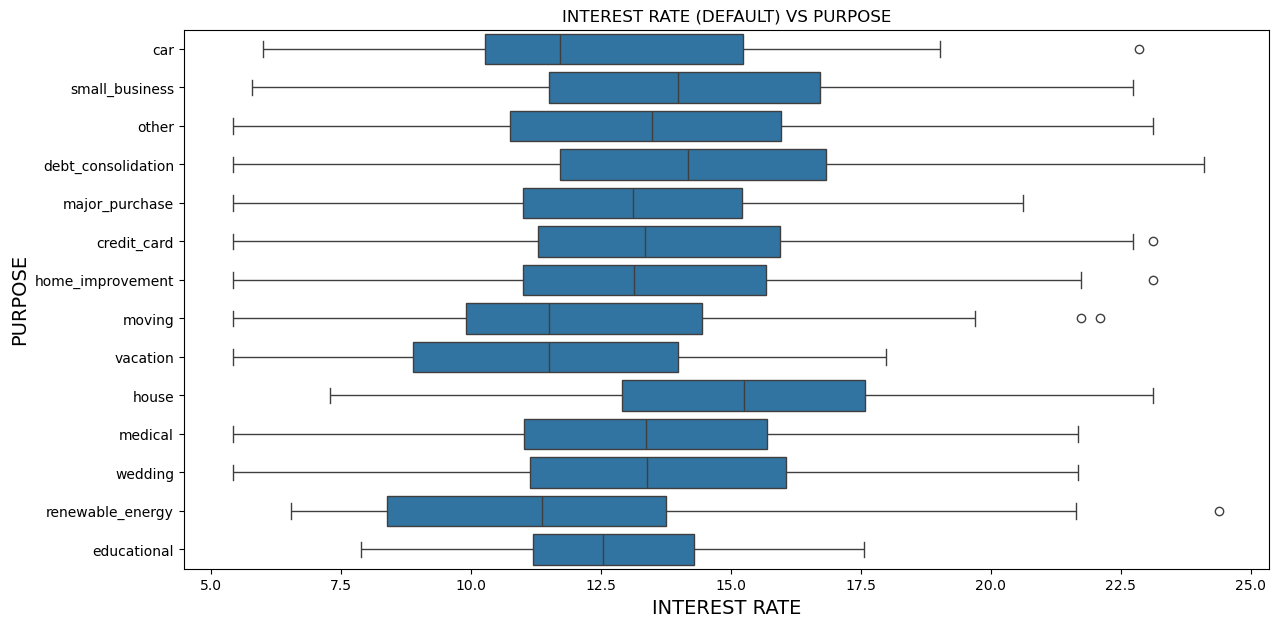

In [55]:
# Box plot for interest rate vs purpose
plt.figure(figsize=(14,7))
viz = sns.boxplot(x='int_rate',
            y='purpose',
            data=co_data)

# Naming the axis and title
viz.set_xlabel('INTEREST RATE', fontsize = 14)
viz.set_ylabel('PURPOSE', fontsize = 14)
viz.set_title('INTEREST RATE (DEFAULT) VS PURPOSE')
plt.show()

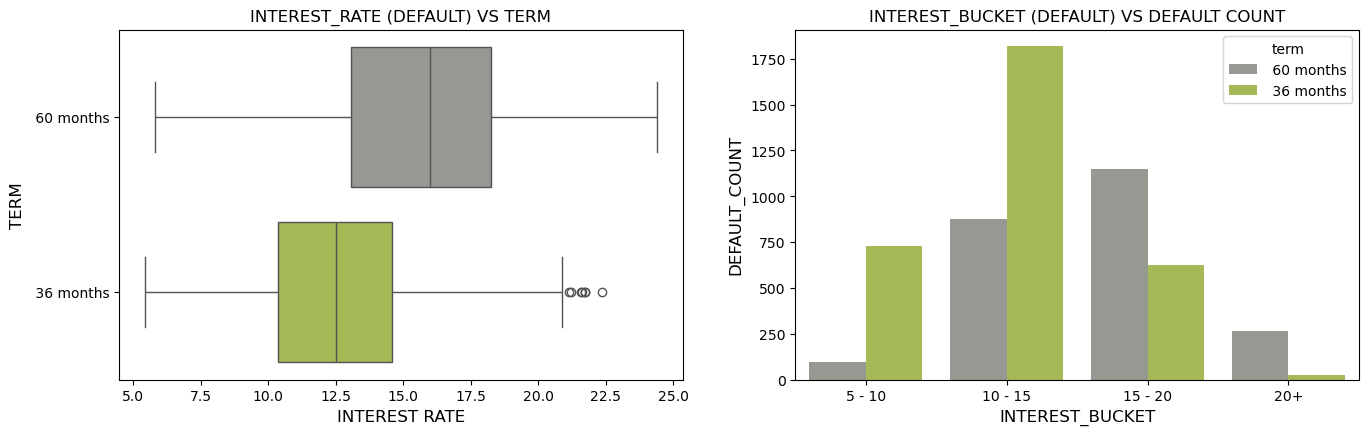

In [56]:
# Box plot for interest rate vs term
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
viz = sns.boxplot(x='int_rate',
            y='term',
            orient = 'h',
            palette=['#979A90',"#AECB46"],
            data=co_data)
# Naming the axis and title
viz.set_xlabel('INTEREST RATE', fontsize = 12)
viz.set_ylabel('TERM', fontsize = 12)
viz.set_title('INTEREST_RATE (DEFAULT) VS TERM')

# Count plot for interest rate vs default count by term as hue
plt.subplot(2,2,2)
viz = sns.countplot(x = 'int_rate_bkt',
              hue= 'term',
              palette=['#979A90', "#AECB46"],
              data = co_data)
# Naming the axis and title
viz.set_xlabel('INTEREST_BUCKET', fontsize = 12)
viz.set_ylabel('DEFAULT_COUNT', fontsize = 12)
viz.set_title('INTEREST_BUCKET (DEFAULT) VS DEFAULT COUNT')

plt.show()

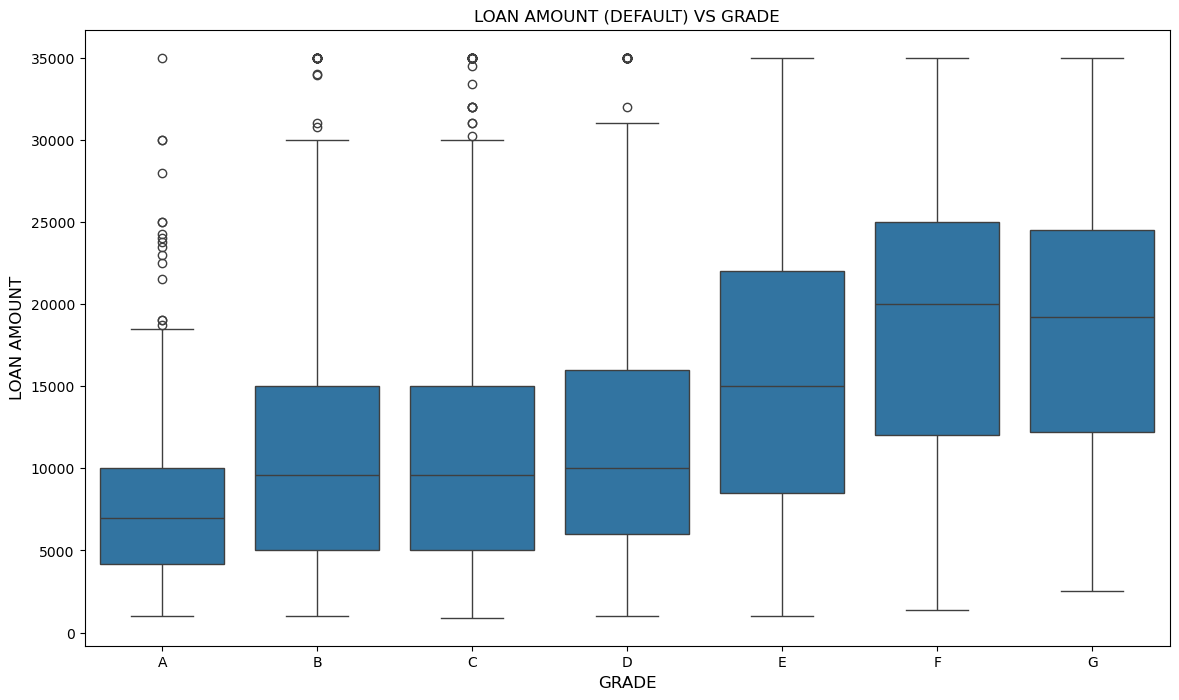

In [57]:
# Box plot for loan amount vs grade
plt.figure(figsize=(14,8))
viz = sns.boxplot(y='loan_amnt',
            x='grade',
            order=['A','B','C','D','E','F','G'],
            data=co_data)

# Naming the axis and title
viz.set_ylabel('LOAN AMOUNT', fontsize = 12)
viz.set_xlabel('GRADE', fontsize = 12)
viz.set_title('LOAN AMOUNT (DEFAULT) VS GRADE')
plt.show()

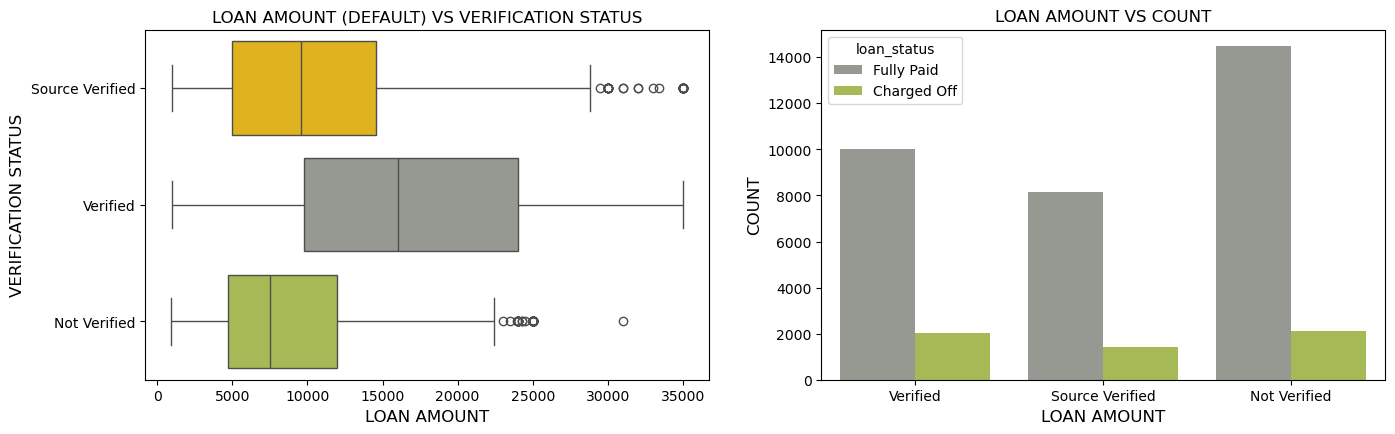

In [59]:
# Box plot for loan amount vs verification status
plt.figure(figsize=(16,10))
plt.subplot(2,2,1)
viz = sns.boxplot(x='loan_amnt',
            y='verification_status',
            orient='h',
            palette=["#FFC300", '#979A90', "#AECB46"],
            data=co_data)
# Naming the axis and title
viz.set_xlabel('LOAN AMOUNT', fontsize = 12)
viz.set_ylabel('VERIFICATION STATUS', fontsize = 12)
viz.set_title('LOAN AMOUNT (DEFAULT) VS VERIFICATION STATUS')

# Count plot for verification status vs count by loan_status as hue
plt.subplot(2,2,2)
viz = sns.countplot(x = 'verification_status',
              hue= data['loan_status'].sort_values(),
              palette=['#979A90', "#AECB46"],
              data = data)
# Naming the axis and title
viz.set_xlabel('LOAN AMOUNT', fontsize = 12)
viz.set_ylabel('COUNT', fontsize = 12)
viz.set_title('LOAN AMOUNT VS COUNT')
plt.show()

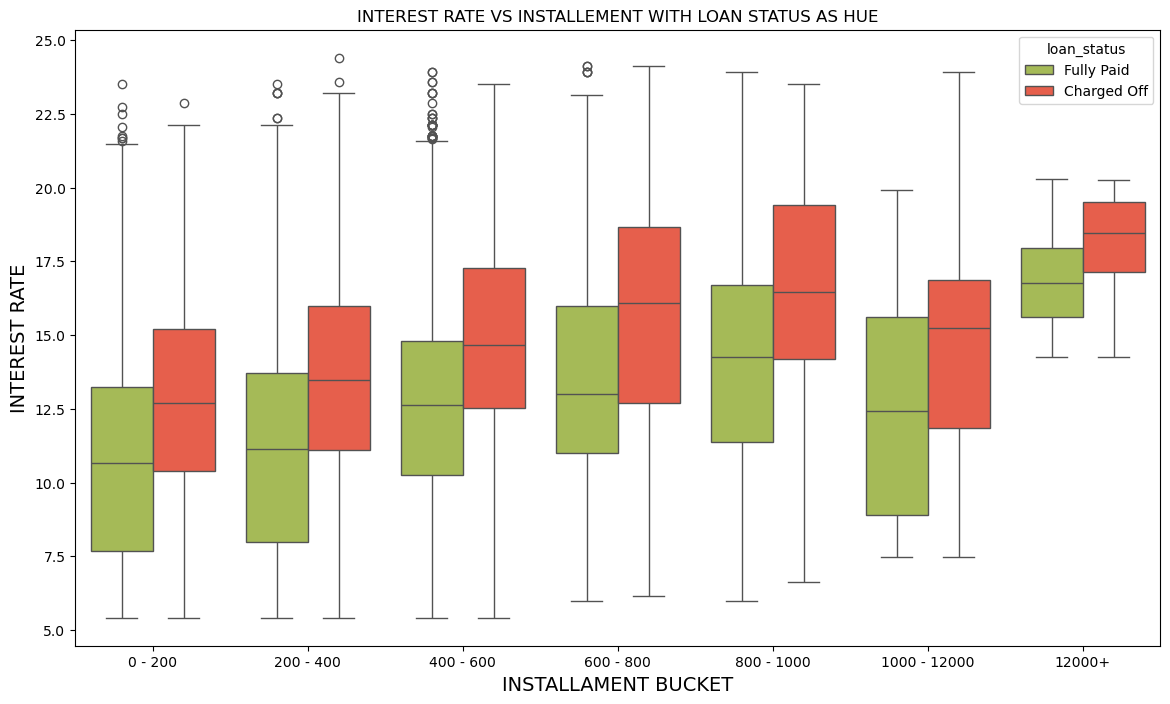

In [60]:
# Box plot for installment bucket vs interest rate by loan status as hue
plt.figure(figsize=(14,8))
viz = sns.boxplot(x='installment_bkt',
            y='int_rate',
            hue = 'loan_status',
            palette=['#AECB46', "#FF4C33"],
            data=data)

# Naming the axis and title
viz.set_xlabel('INSTALLAMENT BUCKET', fontsize = 14)
viz.set_ylabel('INTEREST RATE', fontsize = 14)
viz.set_title('INTEREST RATE VS INSTALLEMENT WITH LOAN STATUS AS HUE')
plt.show()

# OBSERVATION ON BIVARIATE
1. Borrowers with 10+ years of employment length are more likely to charge off.
2. Borrowers living on mortgage with loan amount greater than 12k are likely to charge off.
3. Loan for debt consolidation, credit card, small business with average loan amount greater than 12000 are more likely to default.
4. Loan with highest interest rate in all buckets are more likely to charge off.
5. Loan provided for house, debt consolidation, small business with highest interest rate are more likely to charge off.
6. Longer tenure has the higher interest rate and people in this term with interest rate between 15-20% is more likely to charge off.
7. Shorter tenure has the lower interest rate and people in this term with interest rate between 10-15% is more likely to charge off.
8. Borrower within grade E,F,G and with average loan amount greater than 15000 are more likely to charge off.
9. Borrowers with verification status "not-verified" has loan amount with 5k to 12.5k are more likely to charge off.
10. Borrowers with verification status "not-verified" and "verified" has a equal proportion in charge off.
11. As the number of installment increase the borrowers with high interest rate (>13%) are more likely to charge off.

# MULTIVARIATE

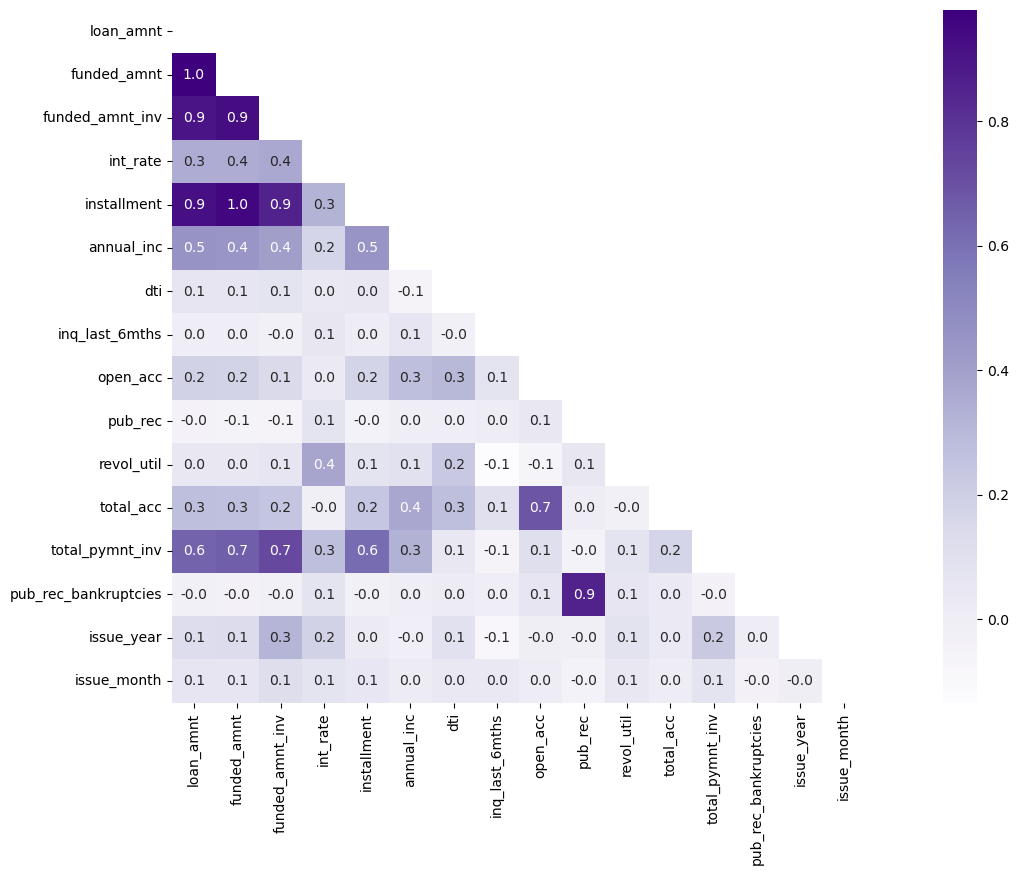

In [61]:
# Creating a correlation heatmap
plt.figure(figsize=(20,9))
correlation = co_data.corr(numeric_only=True)
mask = np.triu(correlation)
sns.heatmap(correlation, annot=True, fmt = '.1f', mask=mask, square=True, cmap='Purples')
plt.show()

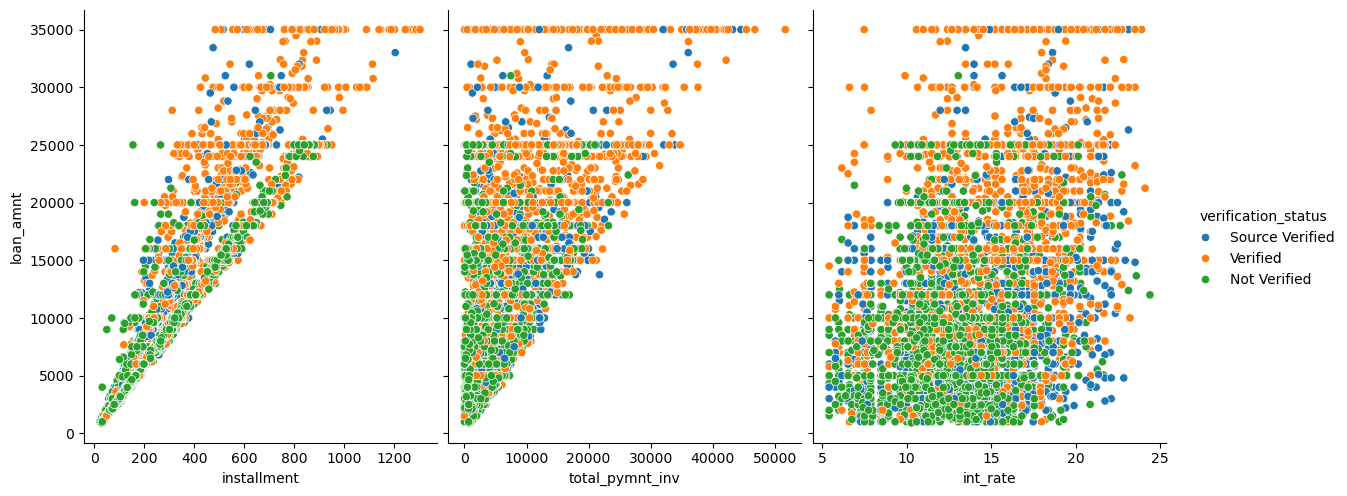

In [62]:
# Plotting a pair plot for 'installment', 'total_pymnt_inv', 'int_rate' vs loan amount by verification status as hue
sns.pairplot(co_data,
             x_vars=['installment', 'total_pymnt_inv', 'int_rate'],
             y_vars=['loan_amnt'],
             diag_kind=None,
             hue='verification_status',
             height=5,
             aspect=0.8,
             kind='scatter')

plt.show()

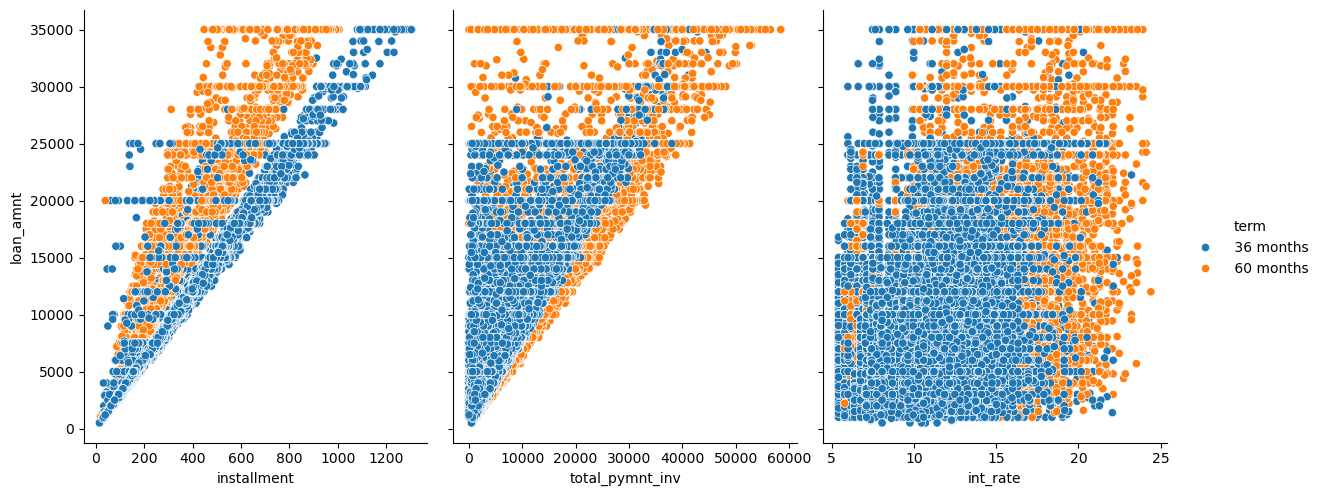

In [63]:
# Plotting a pair plot for 'installment', 'total_pymnt_inv', 'int_rate' vs loan amount by term as hue
sns.pairplot(data,
             x_vars=['installment', 'total_pymnt_inv', 'int_rate'],
             y_vars=['loan_amnt'],
             diag_kind=None,
             hue='term',
             height=5,
             aspect=0.8,
             kind='scatter')

plt.show()

# OBSERVATION FOR MULTIVARIATE ANALYSIS
1. From Correlation Heatmap,

    * loan_amnt has strong positve correlation with installment, total_payment_inv.
    * loan_amnt has intermediate positive correlation with annual_inc, int_rate, total_acc.
    * open_acc has strong positive correlation with total_acc.
    * pub_rec has strong positve correlation with pub_rec_bankruptcies.
   
3. From Pairplot,

   * When the loan amount increases, number of installment, total_pymnt_inv, int_rate also increases.
   * Borrowers with verification status "Not-Verified" are most likely to get loan less than 25k (Charge off).
   * Borrowers with verification status "Verified" are most likely to get loan greater than 25k (Charge off).
   * Borrowers with lower term has higher installments comparatively.
   * Borrowers with 60 months term has highest share to total_pymnt_inv.

   
# DRIVING FACTORS TO CHARGE OFF
1. Borrowers with high interest and 10+ years of employment length.
2. Borrowers living on mortgage with loan amount greater than 12000.
3. Loan for debt consolidation, credit card, small business with loan amount greater than 12000.
4. For any loan amount provided with an average interest rate higher than 13%.
5. Loan provided for house purpose with average interest grater than 15%.
6. Loan provided with an average of 12.5% interest rate for 36months of tenure.
7. Loan provided with an average of 16.5% interest rate for 60months of tenure.
8. Average loan amount greater than 15000 with grade E, F, G.
9. Installments between 800 - 12000 with average interest greater than 15%.
10. Average interest rate of 17% with installment greater than 12000.